<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/AI_Ops/blob/main/Test_Event_Correlation_BGL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload BGL_2k.log (download it from the loghub GitHub repo first):


Saving BGL_2k.log to BGL_2k (1).log
Parsed 2000 events (143 alerts, 1857 non-alert)
Constructed 1965 ground-truth groups (108 real multi-event incidents, rest are singletons)

Computing signals (this is the slow step, only runs once)...
Done.

=== ABLATION STUDY ===
                     config                  weights  best_threshold  precision  recall    f1  n_clusters
Full hybrid (equal weights) (0.25, 0.25, 0.25, 0.25)            0.65      0.132   0.197 0.158        1956
                  Time only     (1.0, 0.0, 0.0, 0.0)            0.45      0.028   0.915 0.055        1115
              Topology only     (0.0, 1.0, 0.0, 0.0)            0.60      0.002   0.099 0.005        1778
                  Text only     (0.0, 0.0, 1.0, 0.0)            0.95      0.007   0.831 0.014        1340
             Frequency only     (0.0, 0.0, 0.0, 1.0)            0.25      0.019   0.099 0.031        1973

=== WEIGHT GRID SEARCH ===
Top 5 weight combinations by F1:
               weights  best_thresho

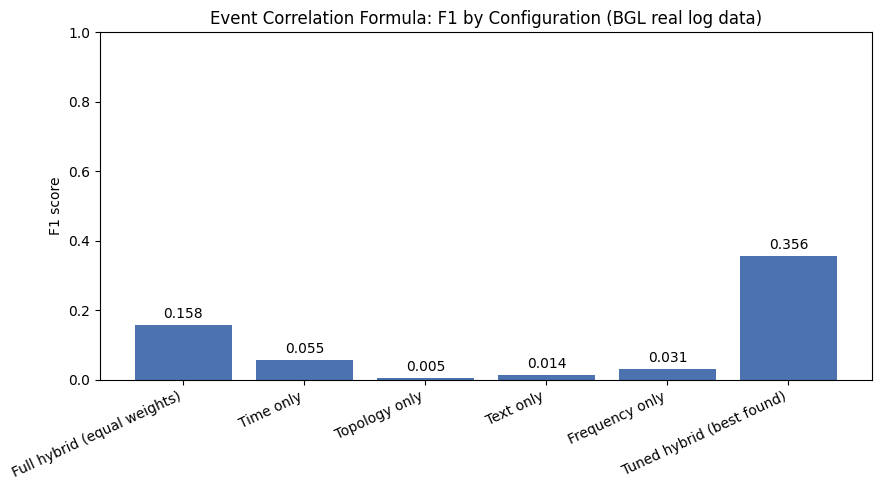


Saved: ablation_results.csv, weight_search_results.csv, ablation_results_chart.png


In [1]:
import re
import numpy as np
import pandas as pd
import networkx as nx
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components as sparse_connected_components
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.cluster import pair_confusion_matrix
from itertools import combinations
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 0: Upload the log file (Colab file picker). If not running in Colab,
# it falls back to looking for BGL_2k.log in the current folder.
# ----------------------------------------------------------------------------
try:
    from google.colab import files
    print("Please upload BGL_2k.log (download it from the loghub GitHub repo first):")
    uploaded = files.upload()
    RAW_LOG_PATH = list(uploaded.keys())[0]
except ImportError:
    RAW_LOG_PATH = "BGL_2k.log"  # running locally: put the file next to this script

# ----------------------------------------------------------------------------
# STEP 1: Parse the raw log + construct a proxy ground truth
# ----------------------------------------------------------------------------
INCIDENT_WINDOW_SECONDS = 60  # alerts within this many seconds chain into one incident
NODE_RE = re.compile(r"^(R\d+)-(M\d+)-")

rows = []
with open(RAW_LOG_PATH, "r", errors="replace") as f:
    for line in f:
        parts = line.strip().split(None, 9)
        if len(parts) < 10:
            continue
        label, timestamp, date, node, time_full, node_repeat, ev_type, component, level, content = parts
        m = NODE_RE.match(node)
        rack = m.group(1) if m else "UNKNOWN"
        midplane = m.group(2) if m else "UNKNOWN"
        rows.append({
            "label": label,
            "timestamp": int(timestamp),
            "node": node,
            "rack": rack,
            "midplane": midplane,
            "type": ev_type,
            "component": component,
            "level": level,
            "content": content,
            "alert_type": f"{ev_type}_{component}_{level}" if label != "-" else "INFO",
            "is_alert": label != "-",
        })

df = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
df["event_id"] = df.index

# Ground truth: alert rows within INCIDENT_WINDOW_SECONDS of each other chain
# together (connected components over time gaps) into one incident.
# Every non-alert row is its own singleton -- it should never be merged.
alert_df = df[df["is_alert"]].copy()
g = nx.Graph()
g.add_nodes_from(alert_df["event_id"])
alert_times = alert_df[["event_id", "timestamp"]].sort_values("timestamp").values
for i in range(len(alert_times)):
    for j in range(i + 1, len(alert_times)):
        if alert_times[j][1] - alert_times[i][1] > INCIDENT_WINDOW_SECONDS:
            break
        g.add_edge(alert_times[i][0], alert_times[j][0])

components_list = list(nx.connected_components(g))
true_incident = {}
for cid, comp in enumerate(components_list):
    for eid in comp:
        true_incident[eid] = f"incident_{cid}"

df["true_incident"] = df["event_id"].map(true_incident)
df["true_incident"] = df.apply(
    lambda r: r["true_incident"] if pd.notna(r["true_incident"]) else f"singleton_{r['event_id']}",
    axis=1,
)

print(f"Parsed {len(df)} events ({df['is_alert'].sum()} alerts, {(~df['is_alert']).sum()} non-alert)")
print(f"Constructed {df['true_incident'].nunique()} ground-truth groups "
      f"({len(components_list)} real multi-event incidents, rest are singletons)\n")

true_labels = df["true_incident"].values

# ----------------------------------------------------------------------------
# STEP 2: Compute the four correlation signals
# ----------------------------------------------------------------------------

def compute_temporal_signal(df, tau=60.0):
    """s_time(i,j) = exp(-|ti - tj| / tau)"""
    times = df["timestamp"].values.astype(float)
    diff = np.abs(times[:, None] - times[None, :])
    return np.exp(-diff / tau)


def compute_topology_signal(df, beta=0.6):
    """
    No real service-dependency graph exists for a supercomputer's compute
    nodes, so this uses the PHYSICAL hierarchy in the node naming scheme
    (Rack -> Midplane -> Node) as a proxy for topological closeness:
      same node                            -> distance 0
      same rack & midplane, different node -> distance 1
      same rack, different midplane        -> distance 2
      different rack                       -> distance 3
    s_topo(i,j) = beta ^ distance
    """
    node = df["node"].values
    rack = df["rack"].values
    midplane = df["midplane"].values
    n = len(df)
    S = np.zeros((n, n))
    for i in range(n):
        same_node = node == node[i]
        same_rack = rack == rack[i]
        same_mid = midplane == midplane[i]
        dist = np.where(
            same_node, 0,
            np.where(same_rack & same_mid, 1,
                     np.where(same_rack, 2, 3))
        )
        S[i] = beta ** dist
    return S


def compute_textual_signal(df):
    """s_text(i,j) = cosine similarity of TF-IDF vectors of alert text."""
    vectorizer = TfidfVectorizer(max_features=2000)
    tfidf = vectorizer.fit_transform(df["content"].values)
    return cosine_similarity(tfidf)


def compute_frequency_signal(df, window_seconds=30):
    """
    s_freq(A,B) = P(A,B) / (P(A) * P(B)) -- a PMI-style frequency-normalization
    (the ACOR-inspired term) computed over the discrete `alert_type` field,
    so it down-weights alert types that are simply very common.
    """
    alert_types = df["alert_type"].values
    times = df["timestamp"].values
    n = len(df)

    unique_types = sorted(set(alert_types))
    type_index = {t: i for i, t in enumerate(unique_types)}
    n_types = len(unique_types)

    order = np.argsort(times)
    sorted_times = times[order]
    sorted_types = alert_types[order]

    window_type_sets = []
    start = 0
    for end in range(n):
        while sorted_times[end] - sorted_times[start] > window_seconds:
            start += 1
        window_type_sets.append(set(sorted_types[start:end + 1]))

    total_windows = n
    type_count = np.zeros(n_types)
    pair_count = np.zeros((n_types, n_types))

    for w in window_type_sets:
        idxs = [type_index[t] for t in w]
        for idx in idxs:
            type_count[idx] += 1
        for a, b in combinations(idxs, 2):
            pair_count[a, b] += 1
            pair_count[b, a] += 1
        for a in idxs:
            pair_count[a, a] += 1

    P_type = type_count / total_windows
    S_type = np.zeros((n_types, n_types))
    for a in range(n_types):
        for b in range(n_types):
            denom = P_type[a] * P_type[b]
            S_type[a, b] = (pair_count[a, b] / total_windows / denom) if denom > 0 else 0.0

    max_val = S_type.max() if S_type.max() > 0 else 1.0
    S_type = S_type / max_val

    type_ids = np.array([type_index[t] for t in alert_types])
    return S_type[np.ix_(type_ids, type_ids)]


def combine_signals(S_time, S_topo, S_text, S_freq, weights):
    w_time, w_topo, w_text, w_freq = weights
    total = w_time + w_topo + w_text + w_freq
    if total == 0:
        raise ValueError("At least one weight must be non-zero")
    return (w_time * S_time + w_topo * S_topo + w_text * S_text + w_freq * S_freq) / total


print("Computing signals (this is the slow step, only runs once)...")
S_time = compute_temporal_signal(df, tau=60.0)
S_topo = compute_topology_signal(df, beta=0.6)
S_text = compute_textual_signal(df)
S_freq = compute_frequency_signal(df, window_seconds=30)
print("Done.\n")

# ----------------------------------------------------------------------------
# STEP 3: Clustering + evaluation (vectorized so it scales to thousands of events)
# ----------------------------------------------------------------------------

def cluster_from_score(Score, threshold):
    """Connected components over a similarity graph -- two events end up in
    the same predicted incident if their score clears the threshold."""
    adj = (Score >= threshold)
    np.fill_diagonal(adj, False)
    sparse_adj = sp.csr_matrix(adj)
    _, labels = sparse_connected_components(sparse_adj, directed=False)
    return labels


def pairwise_prf1(true_labels, pred_labels):
    """Precision/recall/F1 over all PAIRS of events: a pair is a 'positive'
    if both events are predicted to be in the same incident; it's a true
    positive if they're also actually in the same true incident."""
    C = pair_confusion_matrix(true_labels, pred_labels)
    tn, fp = C[0, 0], C[0, 1]
    fn, tp = C[1, 0], C[1, 1]
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def run_config(name, weights, thresholds):
    """Sweeps thresholds and keeps the BEST F1 found for this weight
    configuration -- necessary because different signal combinations produce
    scores on different scales, so one fixed threshold isn't a fair comparison."""
    Score = combine_signals(S_time, S_topo, S_text, S_freq, weights)
    best = {"precision": 0, "recall": 0, "f1": -1, "threshold": None, "n_clusters": None}
    for t in thresholds:
        pred_labels = cluster_from_score(Score, t)
        precision, recall, f1 = pairwise_prf1(true_labels, pred_labels)
        if f1 > best["f1"]:
            best = {"precision": precision, "recall": recall, "f1": f1,
                     "threshold": t, "n_clusters": len(set(pred_labels))}
    return {"config": name, "weights": weights,
            "best_threshold": round(best["threshold"], 2),
            "precision": round(best["precision"], 3),
            "recall": round(best["recall"], 3),
            "f1": round(best["f1"], 3),
            "n_clusters": best["n_clusters"]}


THRESHOLDS = np.arange(0.05, 0.96, 0.05)

# ----------------------------------------------------------------------------
# STEP 4: Ablation study -- each signal alone vs. the full hybrid
# ----------------------------------------------------------------------------
print("=== ABLATION STUDY ===")
ablation_configs = [
    ("Full hybrid (equal weights)", (0.25, 0.25, 0.25, 0.25)),
    ("Time only", (1.0, 0.0, 0.0, 0.0)),
    ("Topology only", (0.0, 1.0, 0.0, 0.0)),
    ("Text only", (0.0, 0.0, 1.0, 0.0)),
    ("Frequency only", (0.0, 0.0, 0.0, 1.0)),
]
ablation_results = [run_config(name, w, THRESHOLDS) for name, w in ablation_configs]
ablation_df = pd.DataFrame(ablation_results)
print(ablation_df.to_string(index=False))

# ----------------------------------------------------------------------------
# STEP 5: Weight grid search -- find a better-than-equal combination
# ----------------------------------------------------------------------------
print("\n=== WEIGHT GRID SEARCH ===")
step = 0.25
weight_values = np.arange(0.0, 1.01, step)
grid_results = []
for w_time in weight_values:
    for w_topo in weight_values:
        for w_text in weight_values:
            for w_freq in weight_values:
                total = w_time + w_topo + w_text + w_freq
                if abs(total - 1.0) > 1e-6:
                    continue
                grid_results.append(run_config("grid", (w_time, w_topo, w_text, w_freq), THRESHOLDS))

grid_df = pd.DataFrame(grid_results).sort_values("f1", ascending=False)
print("Top 5 weight combinations by F1:")
print(grid_df[["weights", "best_threshold", "precision", "recall", "f1"]].head(5).to_string(index=False))

best_weights_row = grid_df.iloc[0]

# ----------------------------------------------------------------------------
# STEP 6: Plot a comparison chart
# ----------------------------------------------------------------------------
labels_for_chart = [r["config"] for r in ablation_results] + ["Tuned hybrid (best found)"]
f1_for_chart = [r["f1"] for r in ablation_results] + [best_weights_row["f1"]]

plt.figure(figsize=(9, 5))
bars = plt.bar(labels_for_chart, f1_for_chart, color="#4C72B0")
plt.ylabel("F1 score")
plt.title("Event Correlation Formula: F1 by Configuration (BGL real log data)")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
for bar, val in zip(bars, f1_for_chart):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.3f}", ha="center")
plt.tight_layout()
plt.savefig("ablation_results_chart.png", dpi=150)
plt.show()

# Save results to CSV so they can be downloaded / put in a report
ablation_df.to_csv("ablation_results.csv", index=False)
grid_df.to_csv("weight_search_results.csv", index=False)
print("\nSaved: ablation_results.csv, weight_search_results.csv, ablation_results_chart.png")